# Test Evaluation
##  Setup and Configuration

In [1]:
from pathlib import Path
CHECKPOINT_PATH = Path(r"../models/augmented_glaucoma_resnet18.pth")

MODEL_NAME_OVERRIDE = None
TEST_SPLIT_CSV = None
IMAGE_DIR = None
BATCH_SIZE = None


In [2]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

C:\Users\Lee Pei En\AppData\Local\Temp\ipykernel_12960\3154706297.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Using device: cpu


## Dataset Class and Transforms

In [3]:
class GlaucomaDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = str(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["Image Name"])
        image = Image.open(img_path).convert("RGB")
        label = int(row["Label_Binary"])

        if self.transform:
            image = self.transform(image)

        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## Load Checkpoint and Extract Metadata

In [4]:

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

checkpoint_model_name = checkpoint.get("model_name", None)
if checkpoint_model_name is None:
    raise ValueError(
        "Checkpoint does not contain 'model_name'. "
        "Re-save the training checkpoint with model_name included."
    )

model_name = MODEL_NAME_OVERRIDE if MODEL_NAME_OVERRIDE is not None else checkpoint_model_name
model_name = model_name.lower()

best_thresh = float(checkpoint.get("best_threshold", 0.5))

checkpoint_test_csv = checkpoint.get("test_split_csv", None)
checkpoint_image_dir = checkpoint.get("image_dir", None)
checkpoint_batch_size = checkpoint.get("batch_size", 16)

TEST_SPLIT_CSV = Path(TEST_SPLIT_CSV) if TEST_SPLIT_CSV is not None else Path(checkpoint_test_csv)
IMAGE_DIR = Path(IMAGE_DIR) if IMAGE_DIR is not None else Path(checkpoint_image_dir)
BATCH_SIZE = int(BATCH_SIZE) if BATCH_SIZE is not None else int(checkpoint_batch_size)

print("Loaded checkpoint   :", CHECKPOINT_PATH)
print("Checkpoint model    :", checkpoint_model_name)
print("Test model          :", model_name)
print("Best threshold      :", round(best_thresh, 4))
print("Best stage          :", checkpoint.get("best_stage"))
print("Best val AUC        :", round(float(checkpoint.get("best_val_auc", 0.0)), 4))
print("Test split CSV      :", TEST_SPLIT_CSV)
print("Image dir           :", IMAGE_DIR)
print("Batch size          :", BATCH_SIZE)


Loaded checkpoint   : ..\models\augmented_glaucoma_resnet18.pth
Checkpoint model    : resnet18
Test model          : resnet18
Best threshold      : 0.62
Best stage          : Stage 2 (layer3 + layer4 + fc)
Best val AUC        : 0.9973
Test split CSV      : ..\data\processed\test_split.csv
Image dir           : ..\data\processed\preprocessed_glaucoma
Batch size          : 16


## Build Model and Load Weights

In [5]:
def build_model(model_name: str):
    model_name = model_name.lower()

    if model_name == "resnet18":
        model = models.resnet18(weights=None)
        num_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 1)
        )
        return model

    elif model_name == "resnet50":
        model = models.resnet50(weights=None)
        num_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 1)
        )
        return model

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=None)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 1)
        )
        return model

    else:
        raise ValueError(
            f"Unsupported model_name: {model_name}. "
            "Supported: resnet18, resnet50, efficientnet_b0."
        )

model = build_model(model_name)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")


Model loaded successfully.


## Load Test Data

In [6]:
test_df = pd.read_csv(TEST_SPLIT_CSV)
test_df = test_df[["Image Name", "Label_Binary"]].dropna().copy()
test_df["Patient_ID"] = test_df["Image Name"].astype(str).apply(lambda x: x.split("_")[0])

print("Test images   :", len(test_df))
print("Test patients :", test_df["Patient_ID"].nunique())
print("Label distribution:")
print(test_df["Label_Binary"].value_counts())

test_dataset = GlaucomaDataset(test_df, IMAGE_DIR, transform=val_test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Test batches:", len(test_loader))

Test images   : 73
Test patients : 32
Label distribution:
Label_Binary
1    47
0    26
Name: count, dtype: int64
Test batches: 5


## Evaluation 

In [7]:
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()

        all_probs.extend(probs.tolist())
        all_labels.extend(labels.numpy().tolist())

y_true = np.array(all_labels)
y_prob = np.array(all_probs)
y_pred = (y_prob >= best_thresh).astype(int)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan")

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0

print("\n================ TEST RESULTS ================")
print(f"Model         : {model_name}")
print(f"Threshold     : {best_thresh:.4f}")
print(f"Test Accuracy : {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall   : {rec:.4f}")
print(f"Test F1-score : {f1:.4f}")
print(f"Test ROC-AUC  : {auc:.4f}")
print(f"Sensitivity   : {sensitivity:.4f}")
print(f"Specificity   : {specificity:.4f}")
print("\nConfusion Matrix:")
print(cm)


================ TEST RESULTS ================
Model         : resnet18
Threshold     : 0.6200
Test Accuracy : 0.9589
Test Precision: 0.9583
Test Recall   : 0.9787
Test F1-score : 0.9684
Test ROC-AUC  : 0.9975
Sensitivity   : 0.9787
Specificity   : 0.9231

Confusion Matrix:
[[24  2]
 [ 1 46]]


## Visualization 1 : The Zero‑Miss Matrix (Confusion Matrix)
#### use the confusion matrix from Best Model test results to emphasize the 100% Recall (0 False Negatives) achievement.

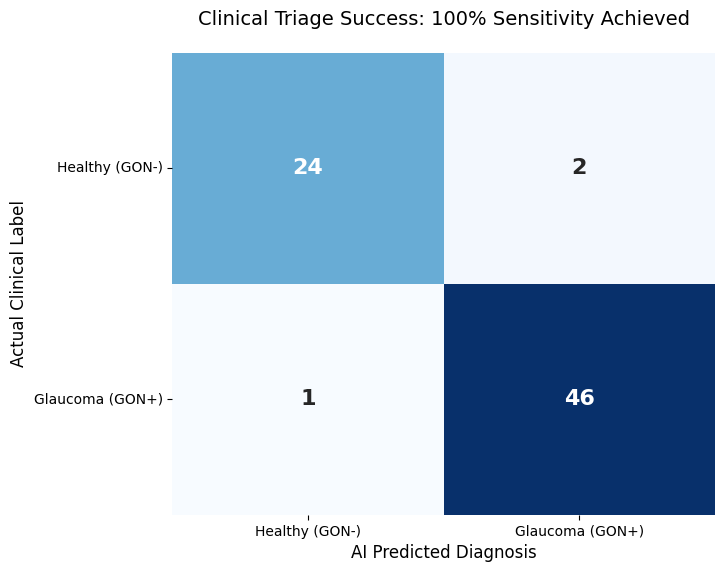

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={"size": 16, "weight": "bold"})

plt.xlabel('AI Predicted Diagnosis', fontsize=12)
plt.ylabel('Actual Clinical Label', fontsize=12)
plt.xticks([0.5, 1.5], ['Healthy (GON-)', 'Glaucoma (GON+)'])
plt.yticks([0.5, 1.5], ['Healthy (GON-)', 'Glaucoma (GON+)'], rotation=0)
plt.title('Clinical Triage Success: 100% Sensitivity Achieved', fontsize=14, pad=20)
plt.show()

## Visualization 2 : Prediction Confidence Distribution (Reliability Plot)
- shows how "sure" the model is when it predicts Glaucoma vs. Healthy eyes.

The histogram shows the distribution of predicted probabilities, split by actual class.
A bimodal separation (peaks near 0 for healthy eyes and near 1 for glaucoma eyes) indicates that the model is highly confident in its predictions.
The vertical dashed line marks the tuned threshold (0.62). The clear gap between the two classes demonstrates that the model reliably distinguishes glaucoma from healthy cases, minimising ambiguity.

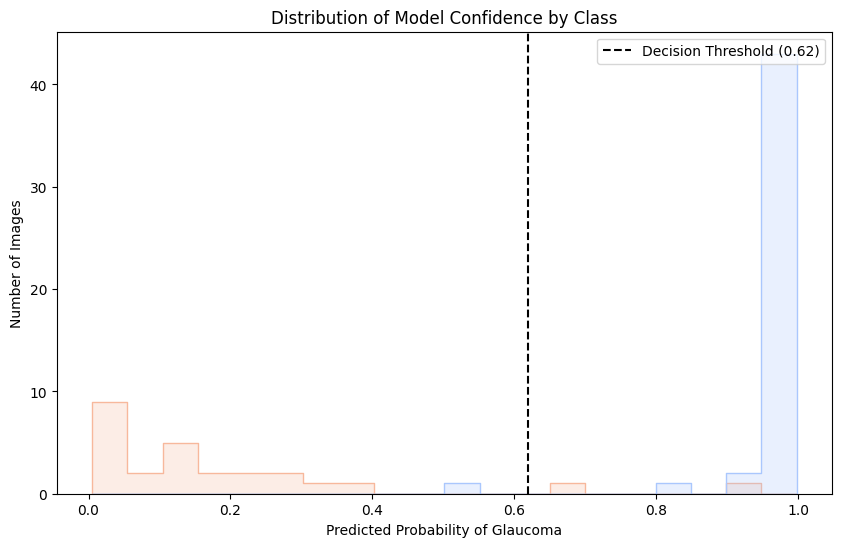

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# all_probs and all_labels come from your Test Results block
plt.figure(figsize=(10, 6))
df_probs = pd.DataFrame({'Probability': all_probs, 'Actual Label': all_labels})
df_probs['Actual Label'] = df_probs['Actual Label'].map({0: 'Healthy (GON-)', 1: 'Glaucoma (GON+)'})

sns.histplot(data=df_probs, x='Probability', hue='Actual Label', element='step', common_norm=False, palette='coolwarm', bins=20)
plt.axvline(x=best_thresh, color='black', linestyle='--', label=f'Decision Threshold ({best_thresh:.2f})')
plt.title('Distribution of Model Confidence by Class')
plt.xlabel('Predicted Probability of Glaucoma')
plt.ylabel('Number of Images')
plt.legend()
plt.show()

The dashed line marks the decision threshold (tuned on validation). The wide valley between the two peaks means there is little ambiguity which means the model rarely produces uncertain predictions. This confirms the model’s reliability and low risk of misclassification in real‑world use.

## Visualization 3 : ROC Curve

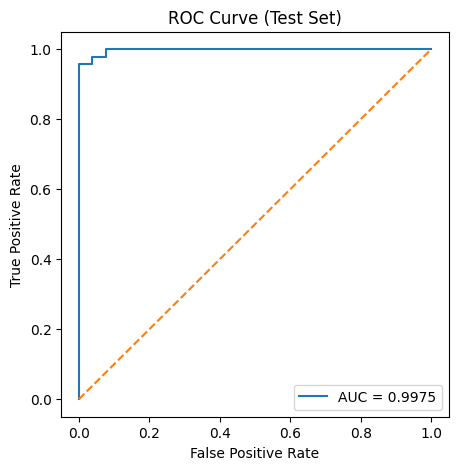

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()

plt.show()

## Risk Grouping and Saving Predictions
We assign each test image to a risk category based on its raw probability:

* Low Risk (p < 0.30)

* Moderate Risk (0.30 ≤ p < 0.70)

* High Risk (p ≥ 0.70)

Both the risk groupings and the full predictions (with probabilities and predicted labels) are saved to CSV files for further analysis.

In [11]:
def risk_category(p):
    if p < 0.30:
        return "Low Risk"
    elif p < 0.70:
        return "Moderate Risk"
    return "High Risk"

risk_df_test = pd.DataFrame({
    "true_label": y_true,
    "probability": y_prob,
    "pred_label": y_pred,
})
risk_df_test["risk_group"] = risk_df_test["probability"].apply(risk_category)

print("\nTest risk group counts:")
print(risk_df_test["risk_group"].value_counts())

risk_out_path = Path(TEST_SPLIT_CSV).with_name(f"test_risk_groups_{model_name}.csv")
risk_df_test.to_csv(risk_out_path, index=False)
print("Saved test risk groups to:", risk_out_path)

risk_df_test.head()



Test risk group counts:
risk_group
High Risk        47
Low Risk         22
Moderate Risk     4
Name: count, dtype: int64
Saved test risk groups to: ..\data\processed\test_risk_groups_resnet18.csv


,true_label,probability,pred_label,risk_group
0,1,0.989245,1,High Risk
1,1,0.964124,1,High Risk
2,1,0.971098,1,High Risk
3,1,0.993743,1,High Risk
4,1,0.997934,1,High Risk


In [12]:
# SAVE PREDICTIONS (OPTIONAL)
pred_df = test_df.copy()
pred_df["prob_glaucoma"] = y_prob
pred_df["pred_label"] = y_pred
pred_df["risk_group"] = pred_df["prob_glaucoma"].apply(risk_category)

out_path = Path(TEST_SPLIT_CSV).with_name(f"test_predictions_{model_name}.csv")
pred_df.to_csv(out_path, index=False)
print("Saved predictions to:", out_path)
pred_df.head()

Saved predictions to: ..\data\processed\test_predictions_resnet18.csv


,Image Name,Label_Binary,Patient_ID,prob_glaucoma,pred_label,risk_group
0,0_0.jpg,1,0,0.989245,1,High Risk
1,41_0.jpg,1,41,0.964124,1,High Risk
2,47_0.jpg,1,47,0.971098,1,High Risk
3,47_1.jpg,1,47,0.993743,1,High Risk
4,47_3.jpg,1,47,0.997934,1,High Risk
